---
# 1. Limpieza final

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

In [52]:
customer = pd.read_csv("customer_numerico.csv", sep=',')
customer.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
# Eliminamos la columna customerID ya que es un identificador sin valor predictivo
customer.drop(columns=['customerID'], inplace=True)

In [54]:
# Se reemplaza los "No phone service" y "No Internet service" porque semanticamente significan lo mismo que "No"
customer = customer.replace({
    'No internet service': 'No',
    'No phone service': 'No'
})

In [55]:
customer['OnlineSecurity'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [56]:
# Identificar variables categoricas
cat_cols = customer.select_dtypes(include=['object']).columns.tolist()
print("Variables categoricas:", cat_cols)

Variables categoricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\Tiffany Mendez\AppData\Local\Temp\ipykernel_17516\1593462003.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = customer.select_dtypes(include=['object']).columns.tolist()


In [57]:
# Aquí se convierten las variables categoricas en numericas. Se hace solo en esas tres columnas porque tienen más de dos variables
customer = pd.get_dummies(customer,
                    columns=['Contract', 'PaymentMethod', 'InternetService'])

In [58]:
customer.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,Female,0,Yes,No,1,No,No,No,Yes,No,...,True,False,False,False,False,True,False,True,False,False
1,Male,0,No,No,34,Yes,No,Yes,No,Yes,...,False,True,False,False,False,False,True,True,False,False
2,Male,0,No,No,2,Yes,No,Yes,Yes,No,...,True,False,False,False,False,False,True,True,False,False
3,Male,0,No,No,45,No,No,Yes,No,Yes,...,False,True,False,True,False,False,False,True,False,False
4,Female,0,No,No,2,Yes,No,No,No,No,...,True,False,False,False,False,True,False,False,True,False


In [59]:
# Se usa for para no repetir todo el código e ir columna por columna
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'Churn', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
               'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check',
               'PaymentMethod_Mailed check', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No']

for col in binary_cols:
    customer[col] = le.fit_transform(customer[col])

In [60]:
customer.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,1,0,0,0,0,1,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,0,0,0,1,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,0,1,0,1,0,0,0,1,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0


In [61]:
# Verificar correlacion de todas las variables con Churn
customer.corr(numeric_only=True)['Churn'].sort_values()

tenure                                    -0.354049
Contract_Two year                         -0.301552
InternetService_No                        -0.227578
TotalCharges                              -0.199484
Contract_One year                         -0.178225
OnlineSecurity                            -0.171270
TechSupport                               -0.164716
Dependents                                -0.163128
Partner                                   -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup                              -0.082307
DeviceProtection                          -0.066193
gender                                    -0.008545
PhoneService                               0.011691
MultipleLines                              0.040033
StreamingMovies                            0.060860
StreamingTV 

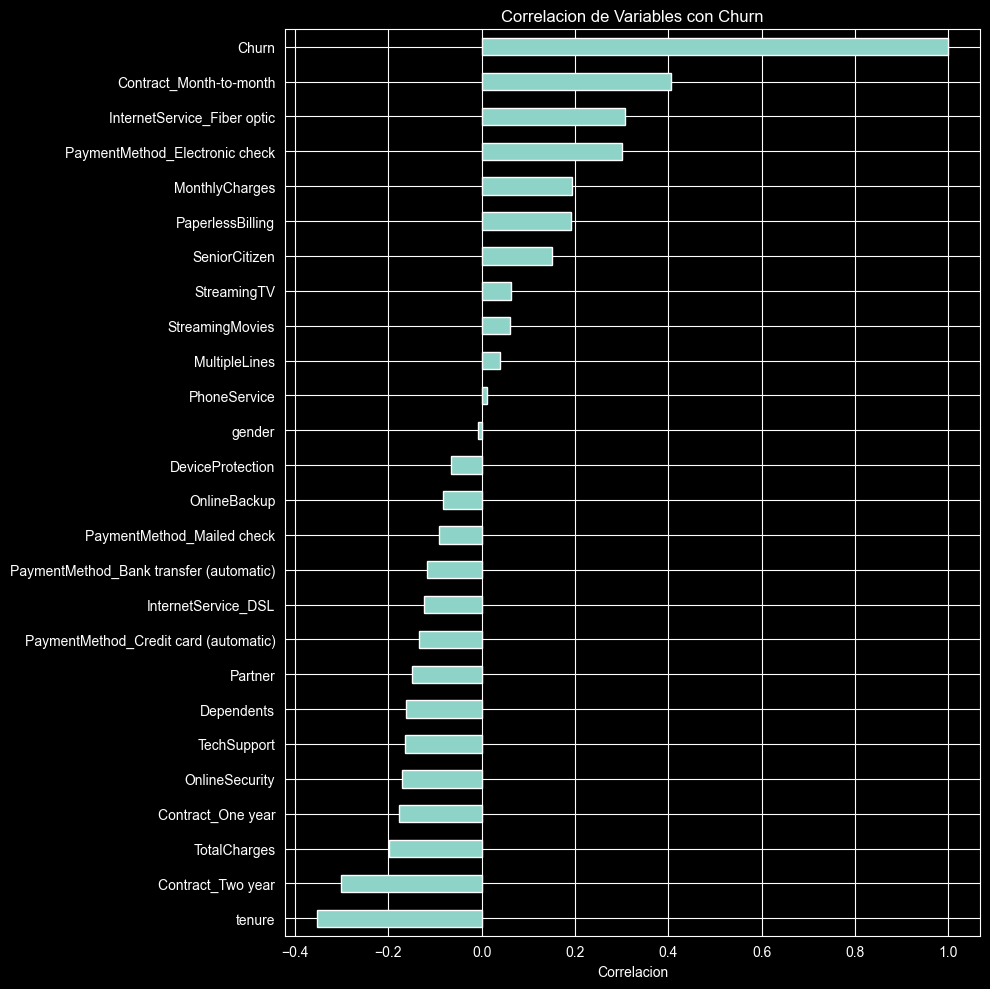

In [62]:
# Grafico de correlacion con Churn
customer.corr(numeric_only=True)['Churn'][:-1].sort_values().plot(kind='barh', figsize=(10, 10))
plt.title('Correlacion de Variables con Churn')
plt.xlabel('Correlacion')
plt.tight_layout()
plt.show()

In [63]:
# Se guarda el csv limpio
customer.to_csv('customer_clean.csv', index=False)

---
# 2. Train Test Split

In [64]:
X = customer.drop('Churn', axis=1).values
y = customer['Churn'].values

In [65]:
X.shape

(7032, 26)

In [66]:
customer.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,1,0,0,0,0,1,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,0,0,0,1,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,0,1,0,1,0,0,0,1,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0


In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=101, stratify=y)

In [68]:
X_train.shape

(5274, 26)

In [69]:
X_test.shape

(1758, 26)

In [70]:
y_train.shape

(5274,)

In [71]:
y_test.shape

(1758,)

In [72]:
pd.DataFrame(X_train).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)
pd.DataFrame(y_train).to_csv('Y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('Y_test.csv', index=False)

---
# 3. Escalado

In [73]:
# StandardScaler: transforma los datos para que tengan media 0 y desviacion estandar 1
scaler = StandardScaler()

In [74]:
scaler.fit(X_train)

StandardScaler()

In [75]:
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

In [76]:
print("Media X_train:", X_train.mean().round(4))
print("Desv. Estandar X_train:", X_train.std().round(4))

Media X_train: -0.0
Desv. Estandar X_train: 1.0


---
# 6. Manejo de Datos Desbalanceados

El dataset tiene aproximadamente **73% No Churn** y **27% Churn**.
Esto es un desbalanceo importante: si no lo corregimos, el modelo aprende a predecir siempre "No Churn" y obtiene 73% de accuracy sin aprender nada útil.

Solución: usamos `class_weight="balanced"` para que el modelo penalice más los errores en la clase minoritaria (Churn=1). Así le damos más importancia a detectar correctamente los clientes que sí se van.

In [79]:
# Calcular los pesos por clase de forma automatica
classes = np.array([0, 1])
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6810433884297521), 1: np.float64(1.8808844507845934)}
